In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score, ConfusionMatrixDisplay, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
import time
import copy
import os

import import_ipynb
import importlib
import functions as fc
importlib.reload(fc)

print(os.getcwd())

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


/Users/elif/Desktop/Projects/privacy_in_ml


In [35]:
diabetes_train = pd.read_csv("datasets/diabetes_train.csv")
diabetes_test = pd.read_csv("datasets/diabetes_test.csv")

----------------------------------------------------------------------------------------------
-------------------------------------- ORIGINAL DATASET --------------------------------------
----------------------------------------------------------------------------------------------

In [36]:
X_train = diabetes_train.drop('Outcome', axis = 1)
X_test = diabetes_test.drop('Outcome', axis = 1)
y_train = diabetes_train['Outcome']
y_test = diabetes_test['Outcome']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### Fit the model

In [37]:
#Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None
model = LogisticRegression(
    penalty="l2",
    C=1,
    max_iter=1000,
    random_state=42
)
model.fit(X_train_sc, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Prediction and utility

In [38]:
print("Training set: ")
fc.predict_binary(model, X_train_sc, y_train, conf_matrix=False)


Training set: 
---------------------------------------
Accuracy: 0.7801
Precision: 0.7241
Recall: 0.5915
F1 Score: 0.6512
---------------------------------------


---------------------------------------
Accuracy: 0.7662
Precision: 0.6863
Recall: 0.6364
F1 Score: 0.6604
---------------------------------------
          Predicted 0  Predicted 1
Actual 0           83           16
Actual 1           20           35


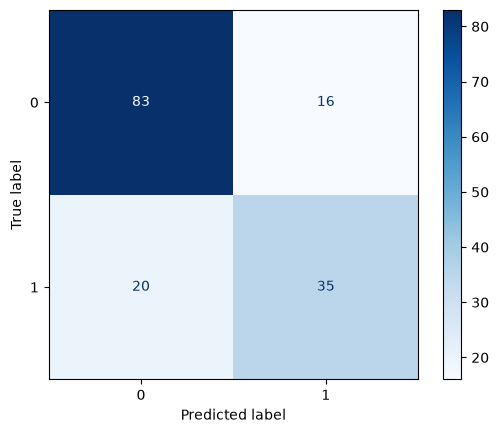

Saved results to results/model_results_diabetes.xlsx


In [39]:
fc.predict_binary_save_results(
    model,
    X_test_sc,
    y_test,
    conf_matrix = True,
    perturbation_type="Original",
    epsilon=0,
    output_file="results/model_results_diabetes.xlsx"
)


In [40]:
fc.cross_validate_model(model, X_train_sc, y_train, cv=5, bivariate = True)

Accuracy: 0.7671
Precision: 0.7082
Recall: 0.5680
F1 Score: 0.6294
Time: 0.014935016632080078


{'fit_time': array([0.00137496, 0.00078893, 0.00066495, 0.00061798, 0.00081635]),
 'score_time': array([0.00204396, 0.00172997, 0.00166011, 0.00195789, 0.00170183]),
 'test_accuracy': array([0.73170732, 0.81300813, 0.75609756, 0.75609756, 0.77868852]),
 'test_precision': array([0.61538462, 0.8125    , 0.68571429, 0.68571429, 0.74193548]),
 'test_recall': array([0.57142857, 0.60465116, 0.55813953, 0.55813953, 0.54761905]),
 'test_f1': array([0.59259259, 0.69333333, 0.61538462, 0.61538462, 0.63013699])}

In [41]:
fc.hyperparameterTuning_save_Results(X_train_sc, y_train, cv=5, bivariate = True, perturbation_type="Original_hpt",
        epsilon=0, output_file="results/model_results_diabetes.xlsx")

Best parameters: {'C': 1}
Accuracy : 0.7671
Precision: 0.7082
Recall   : 0.5680
F1 Score : 0.6294
Time     : 2.08 s


(LogisticRegression(C=1, max_iter=1000), {'C': 1})

----------------------------------------------------------------------------------------------
-------------------------------------- INPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

### Perturb dataset

In [42]:
# Define ranges
ranges = [[0,20], [40,300], [30,200], [5,100], [2,900], [10,70], [0,3], [21,100]]
print(ranges)
sensitivity = []
for range in ranges:
    sensitivity.append(range[1]-range[0])
print(sensitivity)

# sensitivity = []
# for col in X_train.columns:
#     lower = X_train[col].quantile(0.01)
#     upper = X_train[col].quantile(0.99)

#     sensitivity.append(upper-lower)
# print(sensitivity)

[[0, 20], [40, 300], [30, 200], [5, 100], [2, 900], [10, 70], [0, 3], [21, 100]]
[20, 260, 170, 95, 898, 60, 3, 79]


In [43]:
epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]
perturbed_datasets = {}

np.random.seed(42)
for e in epsilon_values:
    X_train_perturbed = X_train.copy()
    d = X_train_perturbed.shape[1]

    for i, var in enumerate(X_train.columns):
        eps_j = e # The paper uses eps_j = e/d, but this leades to huge errors
        scale = sensitivity[i] / eps_j   
        noise = np.random.laplace(loc=0,scale=scale,size=len(X_train))
        #X_train_perturbed[var] = X_train[var] + noise

        lower, upper = ranges[i]
        X_train_perturbed[var] = (
            X_train[var] + noise
        ).clip(lower=lower, upper=upper)

    perturbed_datasets[e] = X_train_perturbed

### Fit the model with the new datasets

In [44]:
for e in epsilon_values:
    input_model = copy.deepcopy(model)

    X_train_input = perturbed_datasets[e]
    scaler = StandardScaler()
    X_train_input_sc = scaler.fit_transform(X_train_input)
    X_test_input_sc = scaler.transform(X_test)

    input_model.fit(X_train_input_sc, y_train)

    # Predict on training set
    print("Training set: ")
    fc.predict_binary(input_model, X_train_input_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_binary_save_results(
        input_model,
        X_test_input_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Input",
        epsilon=e,
        output_file="results/model_results_diabetes.xlsx"
    )

    fc.hyperparameterTuning_save_Results(X_train_input_sc, y_train, cv=10, bivariate = True, perturbation_type="Input_hpt",
        epsilon=e, output_file="results/model_results_diabetes.xlsx")


Training set: 
---------------------------------------
Accuracy: 0.6498
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
---------------------------------------
---------------------------------------
Accuracy: 0.6429
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
---------------------------------------
Saved results to results/model_results_diabetes.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.6531
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
Time     : 0.04 s
Training set: 
---------------------------------------
Accuracy: 0.6564
Precision: 0.6250
Recall: 0.0235
F1 Score: 0.0452
---------------------------------------
---------------------------------------
Accuracy: 0.6429
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
---------------------------------------
Saved results to results/model_results_diabetes.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.6531
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
Time     : 0.04 s
Training set: 
-----------------------

/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

Best parameters: {'C': 0.1}
Accuracy : 0.7152
Precision: 0.6584
Recall   : 0.3855
F1 Score : 0.4825
Time     : 0.04 s
Training set: 
---------------------------------------
Accuracy: 0.7720
Precision: 0.7062
Recall: 0.5869
F1 Score: 0.6410
---------------------------------------
---------------------------------------
Accuracy: 0.7597
Precision: 0.6800
Recall: 0.6182
F1 Score: 0.6476
---------------------------------------
Saved results to results/model_results_diabetes.xlsx
Best parameters: {'C': 1}
Accuracy : 0.7607
Precision: 0.6931
Recall   : 0.5641
F1 Score : 0.6200
Time     : 0.04 s
Training set: 
---------------------------------------
Accuracy: 0.7573
Precision: 0.6860
Recall: 0.5540
F1 Score: 0.6130
---------------------------------------
---------------------------------------
Accuracy: 0.7597
Precision: 0.6800
Recall: 0.6182
F1 Score: 0.6476
---------------------------------------
Saved results to results/model_results_diabetes.xlsx
Best parameters: {'C': 10}
Accuracy : 0.75

----------------------------------------------------------------------------------------------
------------------------------------- OUTPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

In [45]:
n = X_train.shape[0]
C_x = np.max(np.linalg.norm(X_train_sc, axis=1))
lambda_reg = 1 / model.C
sensitivity = (C_x*2) / (lambda_reg * n)

epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]
perturbed_coefficients = {}

np.random.seed(42)
for e in epsilon_values:
    coef_noise = np.random.laplace(loc=0,scale=sensitivity/e, size=model.coef_.shape)
    intercept_noise = np.random.laplace(loc=0,scale=sensitivity /e, size=model.intercept_.shape)
    perturbed_coefficients[e] = {
        "coef": model.coef_ + coef_noise,
        "intercept": model.intercept_ + intercept_noise
    }

In [46]:
for e in epsilon_values:
    output_model = copy.deepcopy(model)

    output_model.coef_ = perturbed_coefficients[e]["coef"]
    output_model.intercept_ = perturbed_coefficients[e]["intercept"]

    # Predict on training set
    print("Training set: ")
    fc.predict_binary(output_model, X_train_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_binary_save_results(
        output_model,
        X_test_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Output",
        epsilon=e,
        output_file="results/model_results_diabetes.xlsx"
    )

Training set: 
---------------------------------------
Accuracy: 0.7476
Precision: 0.6480
Recall: 0.5962
F1 Score: 0.6210
---------------------------------------
---------------------------------------
Accuracy: 0.7143
Precision: 0.6038
Recall: 0.5818
F1 Score: 0.5926
---------------------------------------
Saved results to results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7769
Precision: 0.7235
Recall: 0.5775
F1 Score: 0.6423
---------------------------------------
---------------------------------------
Accuracy: 0.7662
Precision: 0.6863
Recall: 0.6364
F1 Score: 0.6604
---------------------------------------
Saved results to results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7801
Precision: 0.7241
Recall: 0.5915
F1 Score: 0.6512
---------------------------------------
---------------------------------------
Accuracy: 0.7662
Precision: 0.6863
Recall: 0.6364
F1 Score: 0.6604
-------

----------------------------------------------------------------------------------------------
------------------------------------ INTERNAL PERTUBATION ------------------------------------
----------------------------------------------------------------------------------------------

In [47]:
data_norm = np.max(np.linalg.norm(X_train_sc, axis=1))
print("data_norm :", data_norm) #(max L2 norm of a scaled training row)


data_norm : 8.602929272067815


In [48]:
epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]

internal_models = fc.internal_perturbation_save_results(
    "diabetes",
    X_train_sc,
    y_train,
    X_test_sc,
    y_test,
    epsilon_values=epsilon_values,
    data_norm=data_norm,
    C=model.C,
    bivariate=True,
    output_file="results/model_results_diabetes.xlsx",
    perturbation_type="Internal"
)


---------------------------------------
Epsilon: 0.1
Accuracy: 0.5195
Precision: 0.3855
Recall: 0.5818
F1 Score: 0.4638
Time: 0.00 s
---------------------------------------
---------------------------------------
Epsilon: 1
Accuracy: 0.6169
Precision: 0.4722
Recall: 0.6182
F1 Score: 0.5354
Time: 0.00 s
---------------------------------------
---------------------------------------
Epsilon: 5
Accuracy: 0.7403
Precision: 0.6271
Recall: 0.6727
F1 Score: 0.6491
Time: 0.00 s
---------------------------------------
---------------------------------------
Epsilon: 10
Accuracy: 0.7532
Precision: 0.6604
Recall: 0.6364
F1 Score: 0.6481
Time: 0.00 s
---------------------------------------
---------------------------------------
Epsilon: 30
Accuracy: 0.7532
Precision: 0.6604
Recall: 0.6364
F1 Score: 0.6481
Time: 0.00 s
---------------------------------------
---------------------------------------
Epsilon: 50
Accuracy: 0.7532
Precision: 0.6604
Recall: 0.6364
F1 Score: 0.6481
Time: 0.00 s
---------